In [1]:
# Importing Libraries and Loading the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="ticks")
plt.rcParams["figure.figsize"] = (12, 6)
df = pd.read_csv("/content/synthea_healthcaredata.csv")

# Date parsing
for col in ["START", "STOP", "MONTH"]:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

# Basic cleaning
df = df[df["LOS_DAYS"] >= 0]
df["CONDITION_COUNT"] = df["CONDITION_COUNT"].fillna(0)
df["PRIMARY_DIAG_DESC"] = df["PRIMARY_DIAG_DESC"].fillna("Unknown")

# Time features
df["year"] = df["START"].dt.year
df["quarter"] = df["START"].dt.to_period("Q")
df["month"] = df["START"].dt.month

/tmp/ipython-input-1882890094.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/tmp/ipython-input-1882890094.py:14: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)


<Axes: xlabel='quarter_str', ylabel='admissions'>

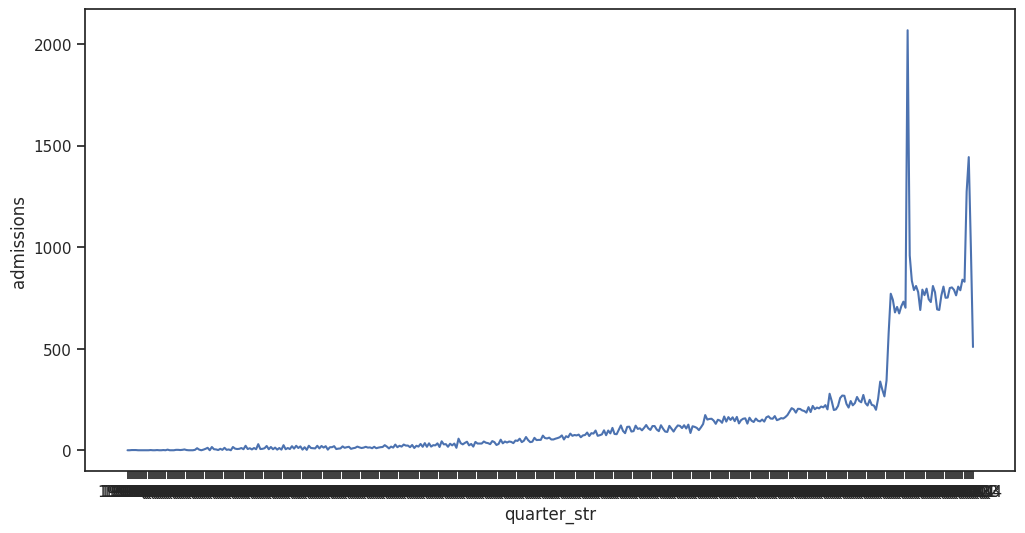

In [9]:
# Question 1 – Quarterly utilisation stability

quarterly_stats = (
    df.groupby("quarter")
      .agg(
          admissions=("ID", "count"),
          los_median=("LOS_DAYS", "median"),
          los_iqr=("LOS_DAYS", lambda x: x.quantile(0.75) - x.quantile(0.25))
      )
      .reset_index()
)

quarterly_stats["quarter_str"] = quarterly_stats["quarter"].astype(str)
sns.lineplot(
    data=quarterly_stats,
    x="quarter_str",
    y="admissions"
)

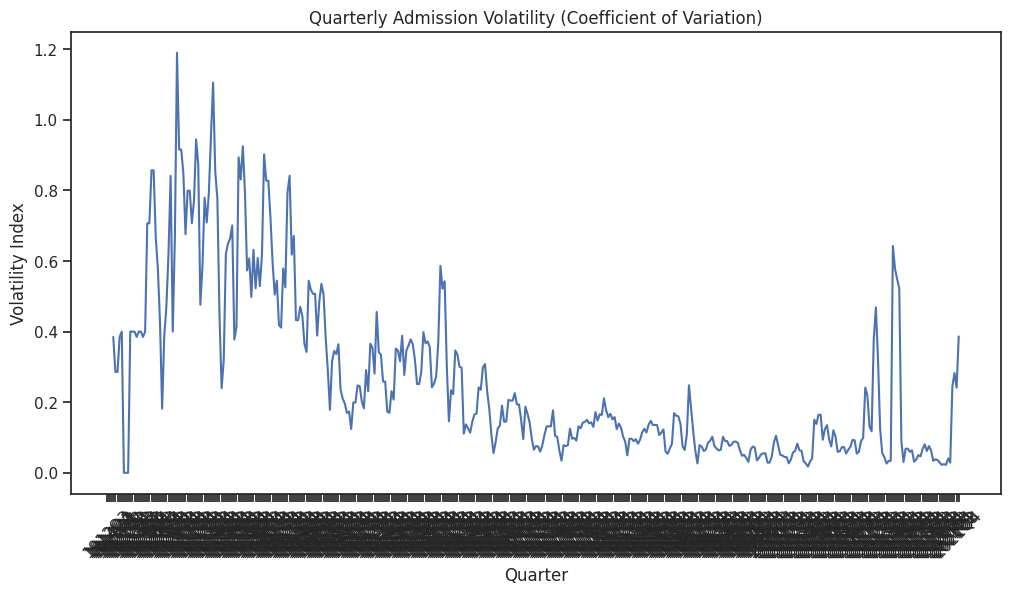

In [10]:
# Admission volatility (advanced metric)

quarterly_stats["admission_cv"] = (
    quarterly_stats["admissions"].rolling(4).std() /
    quarterly_stats["admissions"].rolling(4).mean()
)

sns.lineplot(
    data=quarterly_stats,
    x="quarter_str",
    y="admission_cv"
)

plt.xticks(rotation=45)
plt.title("Quarterly Admission Volatility (Coefficient of Variation)")
plt.xlabel("Quarter")
plt.ylabel("Volatility Index")
plt.show()

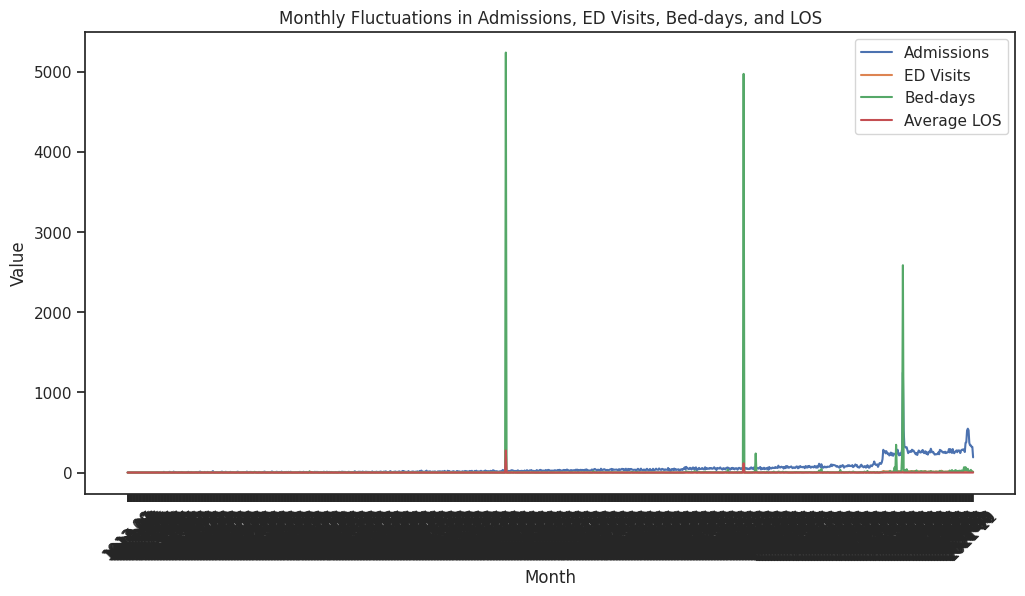

In [15]:
# Monthly utilisation summary

monthly_summary = (
    df.groupby(df["START"].dt.to_period("M"))
      .agg(
          admissions=("ID", "count"),
          ed_visits=("ENCOUNTERCLASS", lambda x: (x.str.lower() == "emergency").sum()),
          bed_days=("LOS_DAYS", "sum"),
          avg_los=("LOS_DAYS", "mean")
      )
      .reset_index()
)

monthly_summary["month_str"] = monthly_summary["START"].astype(str)
plt.figure(figsize=(12,6))

plt.plot(monthly_summary["month_str"], monthly_summary["admissions"], label="Admissions")
plt.plot(monthly_summary["month_str"], monthly_summary["ed_visits"], label="ED Visits")
plt.plot(monthly_summary["month_str"], monthly_summary["bed_days"], label="Bed-days")
plt.plot(monthly_summary["month_str"], monthly_summary["avg_los"], label="Average LOS")

plt.xticks(rotation=45)
plt.title("Monthly Fluctuations in Admissions, ED Visits, Bed-days, and LOS")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.show()

In [16]:
monthly_summary["admission_z"] = (
    (monthly_summary["admissions"] - monthly_summary["admissions"].mean()) /
    monthly_summary["admissions"].std()
)

monthly_outliers = monthly_summary[monthly_summary["admission_z"].abs() > 2]
monthly_outliers

,START,admissions,ed_visits,bed_days,avg_los,month_str,admission_z
1001,2011-12,284,20,5.072616,0.017861,2011-12,2.584008
1002,2012-01,265,17,8.528090,0.032181,2012-01,2.369778
1003,2012-02,266,14,9.564340,0.035956,2012-02,2.381053
1004,2012-03,240,14,5.311262,0.022130,2012-03,2.087896
1005,2012-04,267,14,7.507211,0.028117,2012-04,2.392329
...,...,...,...,...,...,...,...
1115,2021-06,369,17,13.176331,0.035708,2021-06,3.542406
1116,2021-07,340,8,10.678704,0.031408,2021-07,3.215423
1117,2021-08,339,10,33.589931,0.099085,2021-08,3.204148
1118,2021-09,321,13,15.118854,0.047099,2021-09,3.001193


In [3]:
# Question 2 – Efficiency by service line & diagnosis

efficiency_service = (
    df.groupby("ENCOUNTERCLASS")
      .agg(
          encounters=("ID", "count"),
          total_beddays=("LOS_DAYS", "sum")
      )
)

efficiency_service["beddays_per_encounter"] = (
    efficiency_service["total_beddays"] /
    efficiency_service["encounters"]
)

efficiency_service.sort_values(
    "beddays_per_encounter", ascending=False
)
# Diagnosis efficiency (top 10 by volume)
top_diag = df["PRIMARY_DIAG_DESC"].value_counts().head(10).index

diag_efficiency = (
    df[df["PRIMARY_DIAG_DESC"].isin(top_diag)]
    .groupby("PRIMARY_DIAG_DESC")["LOS_DAYS"]
    .quantile([0.5, 0.75, 0.9])
    .unstack()
)

diag_efficiency

,0.50,0.75,0.90
PRIMARY_DIAG_DESC,,,
Encounter for check up (procedure),0.010417,0.010417,0.010417
Encounter for problem,0.041667,1.000000,1.000000
Encounter for problem (procedure),0.010417,0.118403,0.147917
Encounter for symptom,0.010417,0.010417,0.010417
Follow-up encounter,0.010417,0.010417,0.010417
General examination of patient (procedure),0.010417,0.010417,0.010417
Outpatient procedure,0.026331,0.033886,0.038542
Prenatal visit,0.010417,0.010417,0.010417
Urgent care clinic (procedure),0.010417,0.010417,0.010417


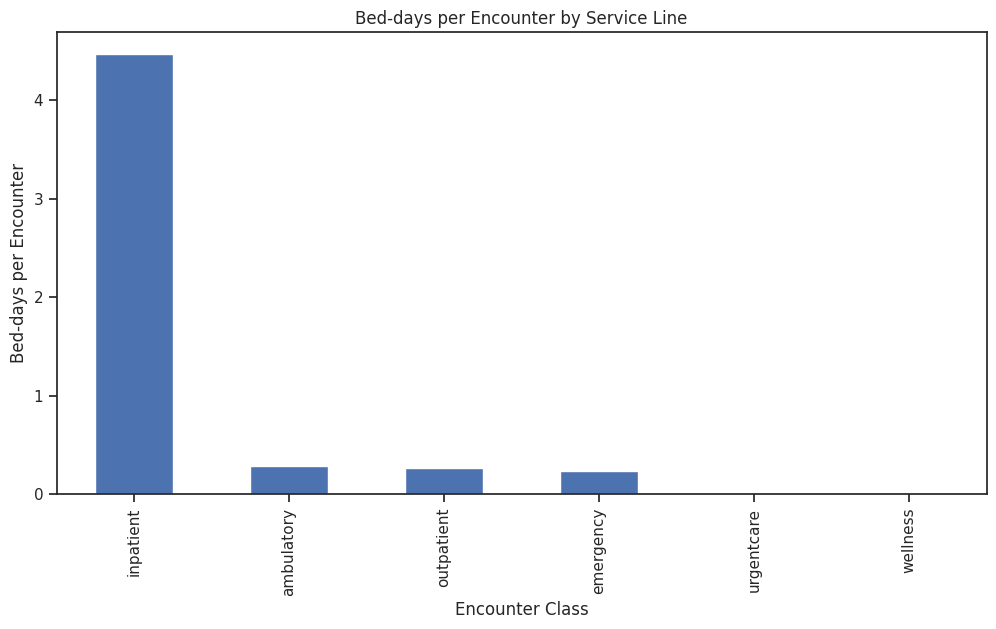

In [11]:
# Bed-days per encounter (efficiency view)

efficiency_service["beddays_per_encounter"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Bed-days per Encounter by Service Line")
plt.xlabel("Encounter Class")
plt.ylabel("Bed-days per Encounter")
plt.show()

In [4]:
# Question 3 – Seasonal sensitivity (normalised approach)

monthly_los = (
    df.groupby(["PRIMARY_DIAG_DESC", "month"])["LOS_DAYS"]
      .mean()
      .reset_index()
)

diag_mean = (
    df.groupby("PRIMARY_DIAG_DESC")["LOS_DAYS"]
      .mean()
      .reset_index(name="overall_mean")
)

seasonal_index = monthly_los.merge(
    diag_mean, on="PRIMARY_DIAG_DESC"
)

seasonal_index["seasonality_ratio"] = (
    seasonal_index["LOS_DAYS"] /
    seasonal_index["overall_mean"]
)
seasonal_variance = (
    seasonal_index.groupby("PRIMARY_DIAG_DESC")["seasonality_ratio"]
    .var()
    .sort_values(ascending=False)
    .head(10)
)

seasonal_variance

,seasonality_ratio
PRIMARY_DIAG_DESC,
Encounter for symptom (procedure),10.643612
Encounter for problem,7.796285
Encounter for problem (procedure),3.152273
Periodic reevaluation and management of healthy individual (procedure),1.605195
Emergency room admission (procedure),0.966868
Emergency Room Admission,0.848179
Admission to intensive care unit (procedure),0.666833
Hospital admission,0.352617
Encounter for check up,0.228854


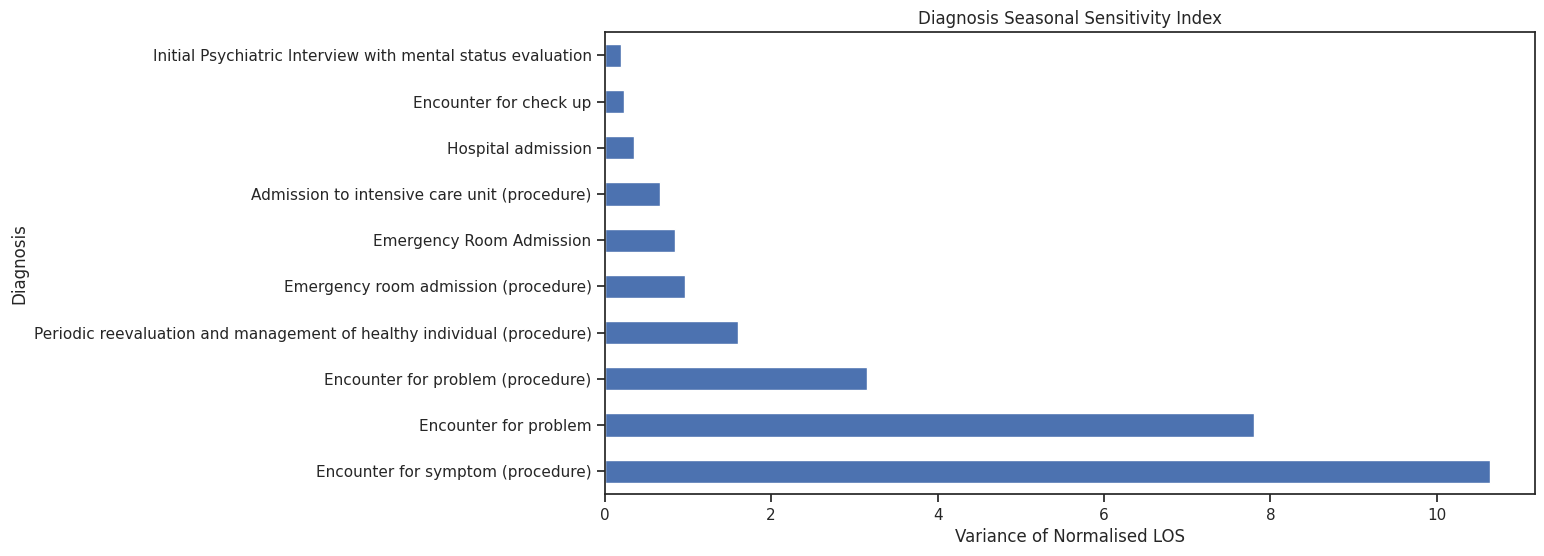

In [12]:
# Seasonal variability index

seasonal_variance.plot(kind="barh")

plt.title("Diagnosis Seasonal Sensitivity Index")
plt.xlabel("Variance of Normalised LOS")
plt.ylabel("Diagnosis")
plt.show()

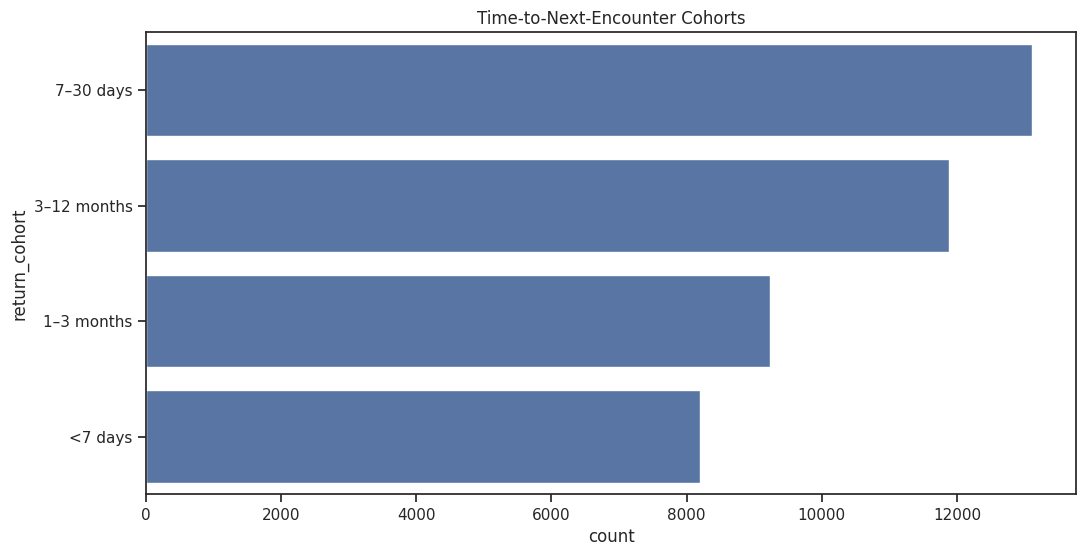

In [5]:
# Question 4 – Time-to-next-encounter analysis

df_sorted = df.sort_values(["PATIENT", "START"])

df_sorted["next_start"] = (
    df_sorted.groupby("PATIENT")["START"].shift(-1)
)

df_sorted["days_to_next"] = (
    df_sorted["next_start"] - df_sorted["STOP"]
).dt.days
# Cohort classification
df_sorted["return_cohort"] = pd.cut(
    df_sorted["days_to_next"],
    bins=[0, 7, 30, 90, 365],
    labels=["<7 days", "7–30 days", "1–3 months", "3–12 months"]
)

df_sorted["return_cohort"].value_counts()
sns.countplot(
    y="return_cohort",
    data=df_sorted,
    order=df_sorted["return_cohort"].value_counts().index
)
plt.title("Time-to-Next-Encounter Cohorts")
plt.show()

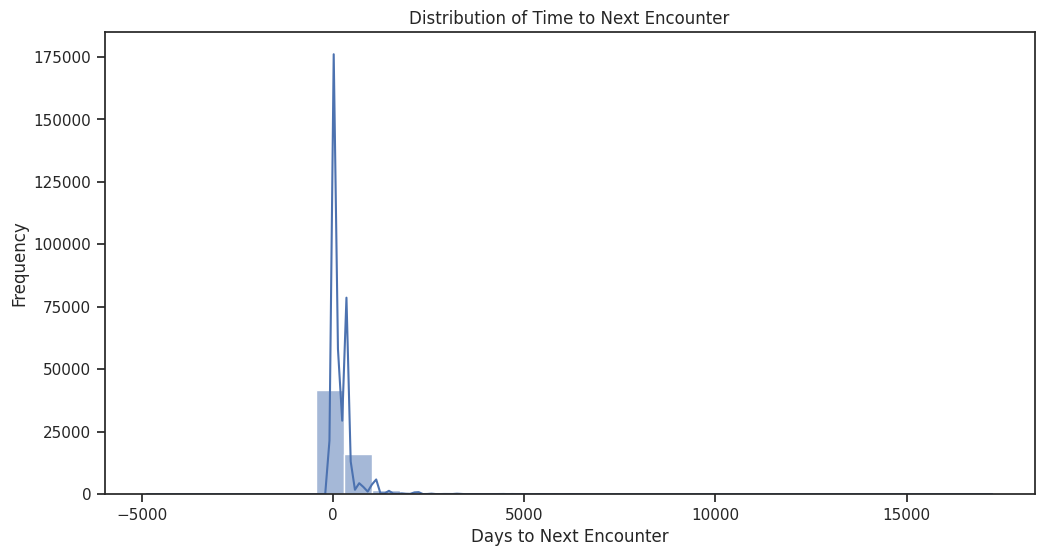

In [13]:
# Distribution of time to next encounter
sns.histplot(
    df_sorted["days_to_next"],
    bins=30,
    kde=True
)

plt.title("Distribution of Time to Next Encounter")
plt.xlabel("Days to Next Encounter")
plt.ylabel("Frequency")
plt.show()

In [6]:
# Care sequence dominance

df_sorted["next_class"] = (
    df_sorted.groupby("PATIENT")["ENCOUNTERCLASS"].shift(-1)
)

sequence_counts = (
    df_sorted.groupby(["ENCOUNTERCLASS", "next_class"])
      .size()
      .sort_values(ascending=False)
      .head(10)
)

sequence_counts

ENCOUNTERCLASS  next_class
wellness        wellness      13630
ambulatory      ambulatory    11003
wellness        ambulatory     6002
ambulatory      wellness       5506
outpatient      outpatient     4641
                wellness       3003
wellness        outpatient     2762
ambulatory      outpatient     1997
outpatient      ambulatory     1667
urgentcare      outpatient     1080
dtype: int64